In [44]:
# Basic libraries for the ML project
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler  # to bring all features to a similar scale
from sklearn.cluster import KMeans  # to group similar data into clusters
from sklearn.metrics import silhouette_score  # to check how good the clusters are
from sklearn.model_selection import train_test_split  # to split data into training and testing
from sklearn.model_selection import StratifiedKFold, cross_val_score # Import cross-validation functions
from sklearn.ensemble import RandomForestClassifier  # Random Forest classification model
from sklearn.metrics import (
    accuracy_score,          # to check the overall accuracy
    classification_report,   # to check precision, recall and F1-score
    confusion_matrix,        # to see correct and wrong predictions
    ConfusionMatrixDisplay   # to display the confusion matrix as a graph
)
import joblib  # to save the trained models

In [45]:
# Load the power-grid dataset
df = pd.read_csv('/content/power_grid.csv')
# Display the first five records
df.head()

,State,Max Demand Met,Shortage During Peak,Energy Met,Drawl Schedule,OD(+) / UD(-),Max OD,Energy Shortage,latitude,longitude,Year,Month,Day
0,Andhra Pradesh,8561.0,0.0,170.1,66.3,-0.5,367.0,0.0,14.750429,78.570026,2020,1,1
1,Arunachal Pradesh,109.0,1.0,2.2,1.9,0.2,34.0,0.0,27.100399,93.616601,2020,1,1
2,Assam,1358.0,28.0,23.4,17.3,1.3,90.0,0.2,26.749981,94.216667,2020,1,1
3,Bihar,4656.0,0.0,82.0,81.2,-0.7,255.0,0.0,25.785414,87.479973,2020,1,1
4,Chandigarh,306.0,0.0,4.9,4.7,0.2,46.0,0.0,30.719997,76.780006,2020,1,1


In [46]:
# Check the number of rows and columns in the dataset
df.shape

(69012, 13)

In [47]:
# Display all the column names in the dataset
df.columns

Index(['State', 'Max Demand Met', 'Shortage During Peak', 'Energy Met',
       'Drawl Schedule', 'OD(+) / UD(-)', 'Max OD', 'Energy Shortage',
       'latitude', 'longitude', 'Year', 'Month', 'Day'],
      dtype='object')

In [48]:
# Check the data types and number of non-null values
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 69012 entries, 0 to 69011
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   State                 69012 non-null  object 
 1   Max Demand Met        69012 non-null  float64
 2   Shortage During Peak  69012 non-null  float64
 3   Energy Met            69012 non-null  float64
 4   Drawl Schedule        69012 non-null  float64
 5   OD(+) / UD(-)         69012 non-null  float64
 6   Max OD                69012 non-null  float64
 7   Energy Shortage       69012 non-null  float64
 8   latitude              69012 non-null  float64
 9   longitude             69012 non-null  float64
 10  Year                  69012 non-null  int64  
 11  Month                 69012 non-null  int64  
 12  Day                   69012 non-null  int64  
dtypes: float64(9), int64(3), object(1)
memory usage: 6.8+ MB


In [49]:
# Check whether the dataset contains any missing values
df.isnull().sum()

,0
State,0
Max Demand Met,0
Shortage During Peak,0
Energy Met,0
Drawl Schedule,0
OD(+) / UD(-),0
Max OD,0
Energy Shortage,0
latitude,0
longitude,0


In [50]:
# Get the statistical summary of numerical features
df.describe()

,Max Demand Met,Shortage During Peak,Energy Met,Drawl Schedule,OD(+) / UD(-),Max OD,Energy Shortage,latitude,longitude,Year,Month,Day
count,69012.000000,69012.000000,69012.000000,69012.000000,69012.000000,69012.000000,69012.000000,69012.000000,69012.000000,69012.000000,69012.000000,69012.000000
mean,5572.517834,30.532756,112.654593,51.311270,-0.011408,277.373614,1.194076,23.230226,81.532618,2022.140845,6.308816,15.725613
std,6493.691430,169.944808,134.268477,62.154497,6.620556,293.999052,9.634746,5.906944,7.347858,1.520171,3.505084,8.798321
min,36.000000,-75.000000,0.000000,-1415.000000,-908.000000,-1065.000000,-43.800000,8.900373,71.192400,2020.000000,1.000000,1.000000
25%,365.000000,0.000000,6.000000,4.600000,-0.900000,44.000000,0.000000,20.381650,76.422495,2021.000000,3.000000,8.000000
50%,2897.000000,0.000000,60.000000,27.500000,-0.100000,201.000000,0.000000,23.798047,78.838100,2022.000000,6.000000,16.000000
75%,9067.000000,0.000000,184.400000,82.500000,0.200000,420.000000,0.000000,27.158632,88.338435,2023.000000,9.000000,23.000000
max,30675.000000,3311.000000,685.000000,1502.000000,66.300000,15623.000000,1153.000000,34.083700,94.216667,2025.000000,12.000000,31.000000


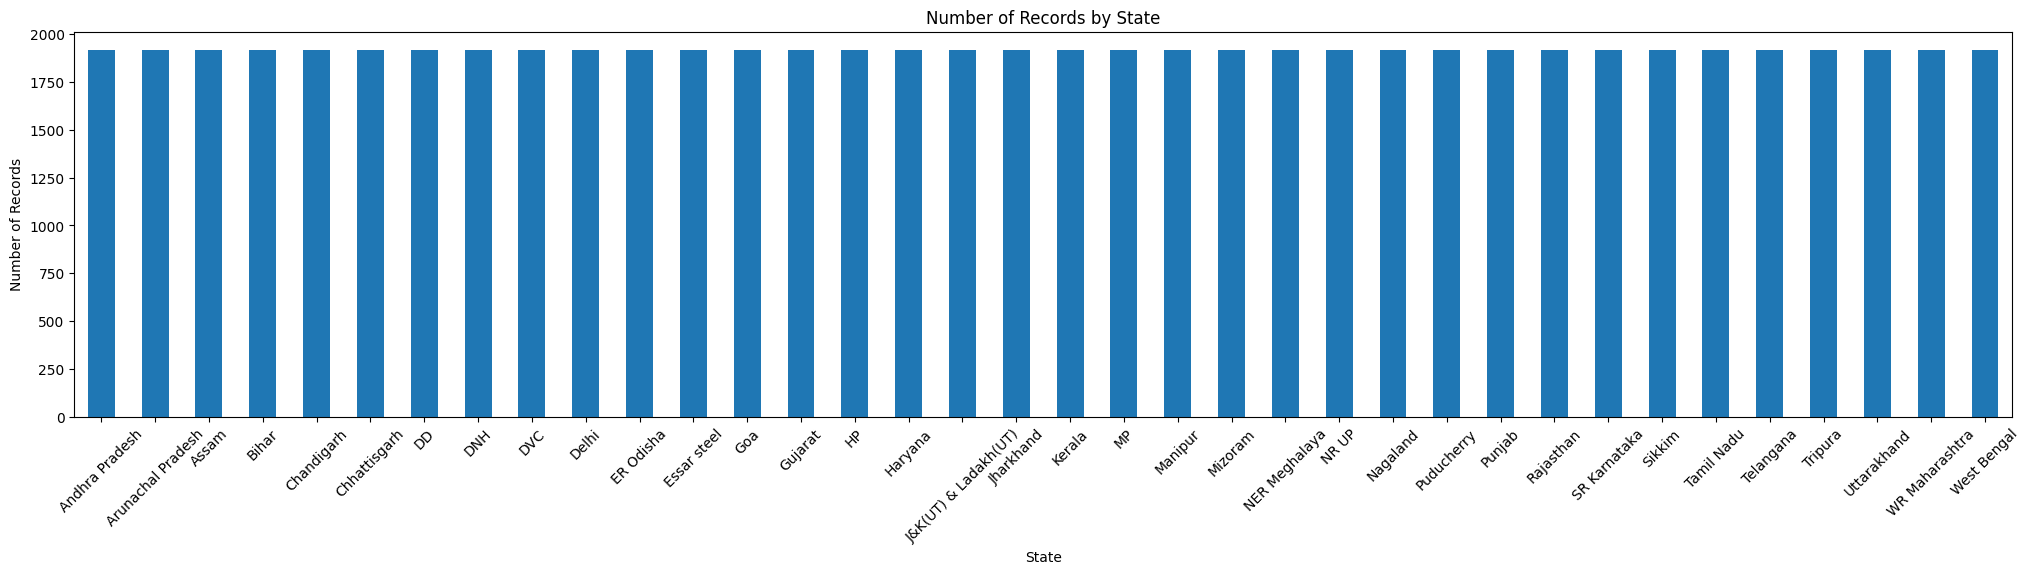

In [51]:
# Count the number of records for each state
# and display it as a bar graph
df['State'].value_counts().plot(
    kind='bar',
    figsize=(25, 5)
)
plt.xlabel("State")
plt.ylabel("Number of Records")
plt.title("Number of Records by State")
# Rotate state names for better readability
plt.xticks(rotation=45)
plt.show()

In [52]:
# Calculate the correlation between numerical grid features
numeric_features = [
    'Max Demand Met',
    'Shortage During Peak',
    'Energy Met',
    'Drawl Schedule',
    'OD(+) / UD(-)',
    'Max OD',
    'Energy Shortage',
    'latitude',
    'longitude',
    'Year',
    'Month',
    'Day'
]
correlation = df[numeric_features].corr()
print(correlation)

                      Max Demand Met  Shortage During Peak  Energy Met  \
Max Demand Met              1.000000             -0.051028    0.995567   
Shortage During Peak       -0.051028              1.000000   -0.061739   
Energy Met                  0.995567             -0.061739    1.000000   
Drawl Schedule              0.867244             -0.001707    0.870452   
OD(+) / UD(-)              -0.090383              0.482540   -0.096551   
Max OD                      0.728545             -0.070915    0.723132   
Energy Shortage            -0.057624              0.720592   -0.066547   
latitude                   -0.177760              0.002327   -0.182592   
longitude                  -0.428219             -0.153514   -0.426789   
Year                        0.083801              0.069749    0.078313   
Month                      -0.015946              0.000688   -0.009989   
Day                         0.001778              0.001856    0.001893   

                      Drawl Schedule 

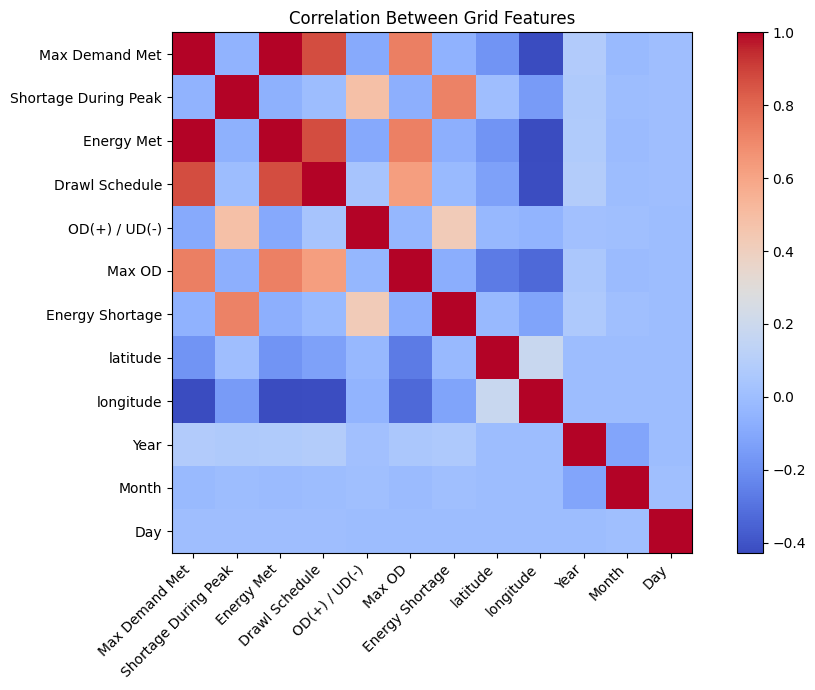

In [53]:
# Create a visual representation of the correlation values
plt.figure(figsize=(10, 7))
plt.imshow(
    correlation,
    cmap='coolwarm'
)
plt.colorbar()
plt.xticks(
    range(len(numeric_features)),
    numeric_features,
    rotation=45,
    ha='right'
)
plt.yticks(
    range(len(numeric_features)),
    numeric_features
)
plt.title("Correlation Between Grid Features")
plt.tight_layout()
plt.show()

# K-Means Clustering

K-Means is an unsupervised machine learning algorithm.
It is used to group similar data into different clusters.

In this project, K-Means is used to group similar power-grid conditions.

In [54]:
# Select the nine features used for K-Means clustering
cluster_features = [
    'latitude',
    'longitude',
    'Max Demand Met',
    'Shortage During Peak',
    'Energy Met',
    'Drawl Schedule',
    'OD(+) / UD(-)',
    'Max OD',
    'Energy Shortage'
]
# Create the input data for K-Means
X_cluster = df[cluster_features]

In [55]:
# Standardize the nine clustering features
# so that they are brought to a similar scale
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_cluster)

# Elbow Method

The Elbow Method is used to find a suitable number of clusters (K)
for the K-Means algorithm.

It uses WCSS (Within-Cluster Sum of Squares) to measure how close
the data points are to their cluster centroids.

When the number of clusters increases, WCSS decreases.

We plot WCSS for different values of K and look for the point where
the decrease starts becoming slower.

This point is called the "Elbow Point" and it helps us select a
suitable value of K.

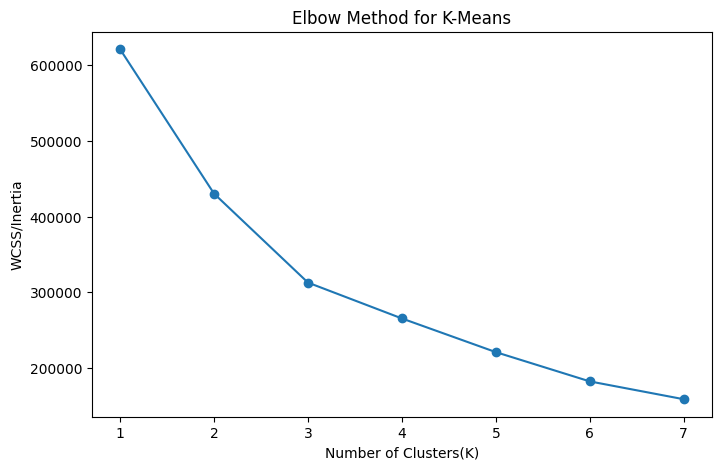

In [56]:
# Store the WCSS value for each K value
wcss = []
# Test different numbers of clusters
for k in range(1, 8):
    kmeans = KMeans(
    n_clusters=k,      # number of clusters to create
    random_state=42,   # keeps the result reproducible
    n_init=10          # tries 10 different initial centroid positions
)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_) # Store the within-cluster error

# Plot the Elbow graph
plt.figure(figsize=(8, 5))
plt.plot(range(1, 8), wcss, marker='o')
plt.xlabel("Number of Clusters(K)")
plt.ylabel("WCSS/Inertia")
plt.title("Elbow Method for K-Means")
plt.show()

# Silhouette Score

Silhouette Score is used to check how well the data points are
grouped into their clusters.

It checks two things:

- How close a data point is to other points in the same cluster.
- How far the data point is from points in other clusters.

The score ranges from -1 to +1.

A higher score means the clusters are better separated.

In this project, we calculate the Silhouette Score for different
values of K and compare the results to select a suitable number
of clusters.

In [57]:
# Store the silhouette score for each K value
silhouette_scores = []

# Test K values from 2 to 7
for k in range(2, 8):
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    # Assign each record to a cluster
    labels = kmeans.fit_predict(X_scaled)
    # Calculate the silhouette score
    score = silhouette_score(X_scaled, labels)
    silhouette_scores.append(score)
    print(f"K = {k}, Silhouette Score = {score:.3f}")

K = 2, Silhouette Score = 0.414
K = 3, Silhouette Score = 0.446
K = 4, Silhouette Score = 0.353
K = 5, Silhouette Score = 0.368
K = 6, Silhouette Score = 0.404
K = 7, Silhouette Score = 0.410


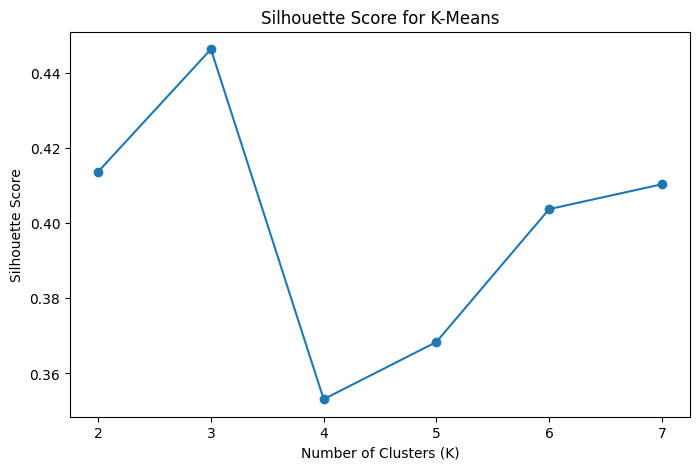

In [58]:
# Plot silhouette scores for different K values
plt.figure(figsize=(8, 5))
plt.plot( range(2, 8), silhouette_scores, marker='o')
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Score for K-Means")
plt.show()

In [59]:
# Create the final K-Means model with three clusters
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
# Assign each record to one of the three clusters
df['Cluster'] = kmeans.fit_predict(X_scaled)
# Display the number of records in each cluster
print(df['Cluster'].value_counts().sort_index())

Cluster
0    18798
1    49109
2     1105
Name: count, dtype: int64


In [60]:
# Get the cluster centers and convert them back to the original feature scale
centers = scaler.inverse_transform(kmeans.cluster_centers_)

centers = pd.DataFrame(
    centers,
    columns=cluster_features
)

# Display latitude and longitude of each centroid
print(centers[['latitude', 'longitude']])

    latitude  longitude
0  20.615547  76.716574
1  24.291676  83.560324
2  20.467179  73.215595


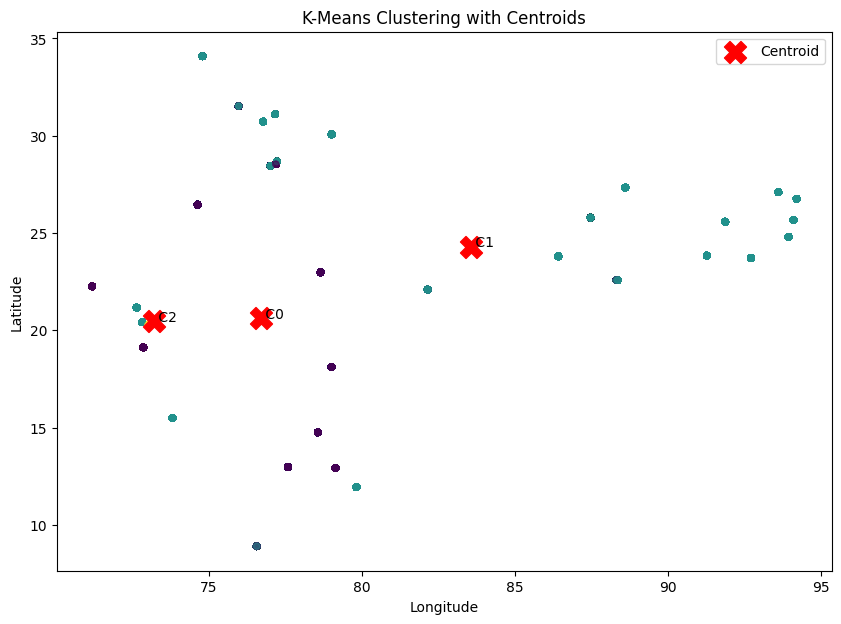

In [61]:
# Create a geographical visualization of the clusters
plt.figure(figsize=(10, 7))

# Plot all observations using longitude and latitude
# Color represents the K-Means cluster
plt.scatter(
    df['longitude'],
    df['latitude'],
    c=df['Cluster'],
    cmap='viridis',
    s=20,
    alpha=0.6
)

# Plot the cluster centroids as red X marks
plt.scatter(
    centers['longitude'],
    centers['latitude'],
    marker='X',
    s=250,
    color='red',
    label='Centroid'
)

# Add cluster labels near each centroid
for i in range(3):
    plt.text(
        centers['longitude'].iloc[i],
        centers['latitude'].iloc[i],
        f' C{i}'
    )

plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("K-Means Clustering with Centroids")
plt.legend()

plt.show()

# K-Means Centroids

A centroid is the center point of a cluster.

It represents the average characteristics of all the data points
that belong to that cluster.

In our project, K-Means creates 3 clusters.

Each cluster has one centroid, and each centroid contains values
for all 9 selected features.

The centroid helps us understand the characteristics of each cluster.

Since K-Means is trained on standardized data, we convert the
centroids back to the original scale for easier interpretation.

**Display All Centroids**

In [62]:
centers = scaler.inverse_transform(kmeans.cluster_centers_) # Convert the cluster centers back to the original data scale

centers = pd.DataFrame(
    centers,
    columns=cluster_features
)

print(centers)

    latitude  longitude  Max Demand Met  Shortage During Peak  Energy Met  \
0  20.615547  76.716574    14653.155452             12.255492  298.995324   
1  24.291676  83.560324     2196.790956             10.094879   43.664927   
2  20.467179  73.215595     1357.430940           1249.813372   13.597949   

   Drawl Schedule  OD(+) / UD(-)      Max OD  Energy Shortage  
0      128.329639      -0.782319  612.351859         0.363696  
1       22.290653      -0.327366  154.968452         0.229910  
2       32.857856      27.136486   27.490457        58.172865  


# Risk Score

K-Means gives us cluster numbers, but it does not directly give
Low, Medium, or High risk.

So, we calculate a risk score for each cluster using important
grid-risk features.

In our project, we use:

- Shortage During Peak
- Energy Shortage
- Max OD
- OD(+) / UD(-)

The values are standardized and combined to calculate the risk score.

A higher risk score represents more critical grid conditions.

The clusters are then arranged from the lowest score to the
highest score and assigned as:

Low Risk → Medium Risk → High Risk

**Calculate Risk Score**

In [63]:
# Select the features that represent important grid-risk conditions
risk_features = [
    'Shortage During Peak',
    'Energy Shortage',
    'Max OD',
    'OD(+) / UD(-)'
]

risk_data = centers[risk_features]

risk_scaled = (risk_data - risk_data.mean()) / risk_data.std(ddof=0)

risk_score = risk_scaled.mean(axis=1)

print(risk_score)

0   -0.187715
1   -0.636513
2    0.824228
dtype: float64


**Map Cluster to Risk**

In [64]:
# Arrange the clusters from lowest risk score to highest risk score
risk_order = risk_score.sort_values().index

# Define the three risk levels
risk_labels = ['Low', 'Medium', 'High']

# Map each cluster to its risk level
cluster_to_risk = {
    cluster: risk_labels[i]
    for i, cluster in enumerate(risk_order)
}
print(cluster_to_risk)

{1: 'Low', 0: 'Medium', 2: 'High'}


In [65]:
# Convert the cluster number into its corresponding risk level
df['Risk'] = df['Cluster'].map(cluster_to_risk)
print(df[['Cluster', 'Risk']].head())

   Cluster    Risk
0        0  Medium
1        1     Low
2        1     Low
3        1     Low
4        1     Low


In [66]:
df.head()

,State,Max Demand Met,Shortage During Peak,Energy Met,Drawl Schedule,OD(+) / UD(-),Max OD,Energy Shortage,latitude,longitude,Year,Month,Day,Cluster,Risk
0,Andhra Pradesh,8561.0,0.0,170.1,66.3,-0.5,367.0,0.0,14.750429,78.570026,2020,1,1,0,Medium
1,Arunachal Pradesh,109.0,1.0,2.2,1.9,0.2,34.0,0.0,27.100399,93.616601,2020,1,1,1,Low
2,Assam,1358.0,28.0,23.4,17.3,1.3,90.0,0.2,26.749981,94.216667,2020,1,1,1,Low
3,Bihar,4656.0,0.0,82.0,81.2,-0.7,255.0,0.0,25.785414,87.479973,2020,1,1,1,Low
4,Chandigarh,306.0,0.0,4.9,4.7,0.2,46.0,0.0,30.719997,76.780006,2020,1,1,1,Low


In [67]:
df.columns

Index(['State', 'Max Demand Met', 'Shortage During Peak', 'Energy Met',
       'Drawl Schedule', 'OD(+) / UD(-)', 'Max OD', 'Energy Shortage',
       'latitude', 'longitude', 'Year', 'Month', 'Day', 'Cluster', 'Risk'],
      dtype='object')

In [68]:
# Check how many records belong to each risk category
df['Risk'] = df['Cluster'].map(cluster_to_risk)
print(df['Risk'].value_counts())

Risk
Low       49109
Medium    18798
High       1105
Name: count, dtype: int64


In [69]:
# Check the number of records in each cluster and risk category
print(df[['Cluster', 'Risk']].value_counts().sort_index())

Cluster  Risk  
0        Medium    18798
1        Low       49109
2        High       1105
Name: count, dtype: int64


# Random Forest Classification

Random Forest is a supervised machine learning algorithm used for
classification and prediction.

It combines multiple decision trees to make a final prediction.

In this project, Random Forest is used to predict the risk level
of a power-grid observation.

The input features are the nine power-grid features.

The target is the Risk category:

- Low Risk
- Medium Risk
- High Risk

The model learns the relationship between the grid conditions
and the risk levels from the training data.

In [70]:
# Select the nine grid features as input variables
X = df[cluster_features]
# Use Risk as the target variable
y = df['Risk']

In [71]:
# Split the data into training and testing sets
# 80% for training and 20% for testing
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [72]:
# Create the Random Forest classification model
rf_model = RandomForestClassifier(
    n_estimators=100,       # number of decision trees
    random_state=42,        # to get reproducible results
    class_weight='balanced' # to handle unequal class distribution
)

In [73]:
rf_model.fit(X_train, y_train)

RandomForestClassifier(class_weight='balanced', random_state=42)

In [74]:
y_pred = rf_model.predict(X_test)
print(y_pred[:10]) # Display the first ten predictions

['Low' 'Low' 'Low' 'Low' 'Medium' 'Low' 'Low' 'Low' 'Low' 'Medium']


# Random Forest Model Testing and Evaluation

After training the Random Forest model, we test it using unseen test data.

The following metrics are used to check the model performance:

### 1. Accuracy
Shows the overall percentage of predictions that are correct.

### 2. Precision
Shows how many of the predicted risk classes are actually correct.

### 3. Recall
Shows how many of the actual risk classes are correctly identified by the model.

### 4. F1-Score
Combines Precision and Recall into one value.

### 5. Confusion Matrix
Shows the number of correct and incorrect predictions for
Low, Medium, and High risk.

### 6. Training vs Testing Accuracy
Compares the model performance on training data and unseen test data.
This helps us check whether the model is generalizing well.

### 7. Cross-Validation
Tests the model on different subsets of the data to check
whether the performance is consistent.

These metrics help us understand not only how accurate the model is,
but also how well it performs for each risk category.

In [75]:
# Calculate the accuracy of the Random Forest using the unseen test data
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

Accuracy: 0.9967398391653989


In [76]:
print(classification_report(y_test, y_pred)) # Generate the classification report

              precision    recall  f1-score   support

        High       1.00      0.98      0.99       221
         Low       1.00      1.00      1.00      9822
      Medium       0.99      1.00      0.99      3760

    accuracy                           1.00     13803
   macro avg       1.00      0.99      0.99     13803
weighted avg       1.00      1.00      1.00     13803



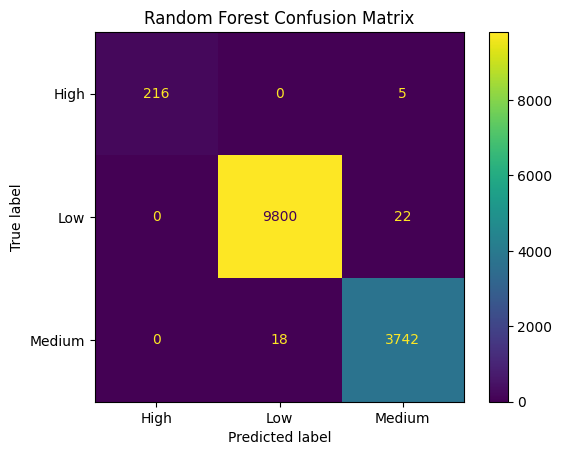

In [77]:
cm = confusion_matrix(y_test, y_pred) # Create the confusion matrix

# Create a visual display of the confusion matrix
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=rf_model.classes_
)
disp.plot()
plt.title("Random Forest Confusion Matrix")
plt.show()

In [78]:
train_pred = rf_model.predict(X_train) # Predict the training data

train_accuracy = accuracy_score(y_train, train_pred) # Calculate training accuracy

print("Training Accuracy:", train_accuracy)
print("Testing Accuracy:", accuracy)

Training Accuracy: 1.0
Testing Accuracy: 0.9967398391653989


# Feature Importance

Feature importance shows which features are more important
for the Random Forest prediction.

A higher importance value means the feature has a greater
contribution to the model's prediction.

This helps us understand which power-grid features are
more influential in predicting the risk level.

In [82]:
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by='Importance', ascending=False
) # Sort the features by importance in descending order

print(feature_importance)

                Feature  Importance
4            Energy Met    0.238358
3  Shortage During Peak    0.201074
2        Max Demand Met    0.170291
7                Max OD    0.103729
8       Energy Shortage    0.102294
6         OD(+) / UD(-)    0.086283
5        Drawl Schedule    0.068257
1             longitude    0.022635
0              latitude    0.007080


## Feature Importance Graph

The graph provides a visual representation of the feature
importance values.

The features with larger values have a greater contribution
to the Random Forest classification.

**Feature Importance Graph**

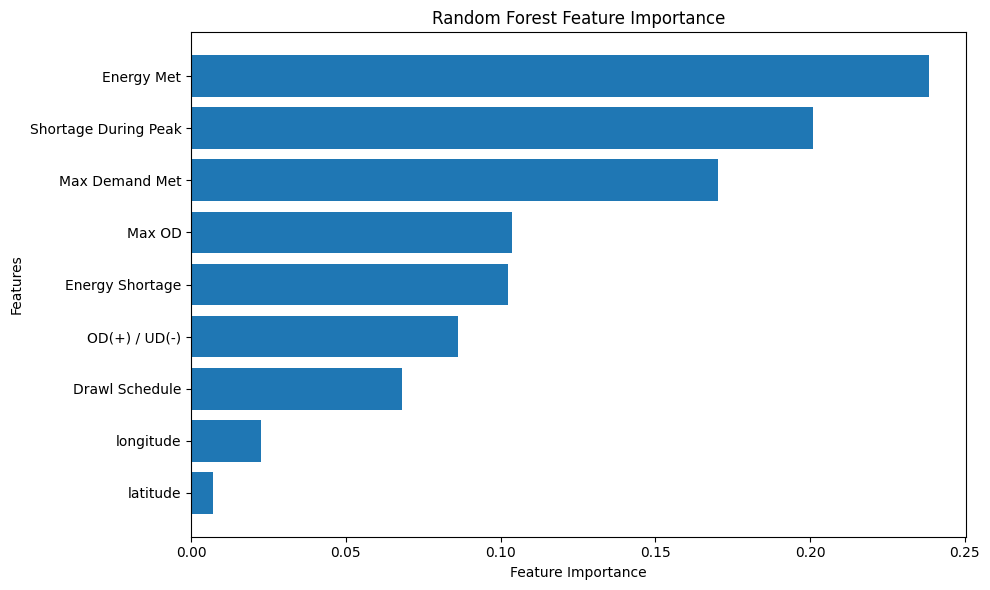

In [83]:
# Create a graph to visualize feature importance
plt.figure(figsize=(10, 6))

plt.barh(
    feature_importance['Feature'],
    feature_importance['Importance']
)

plt.xlabel("Feature Importance")
plt.ylabel("Features")
plt.title("Random Forest Feature Importance")

# Display the most important feature at the top
plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()

In [84]:
# Create five stratified folds
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)
# Evaluate the model using F1-score
# across all five folds
cv_scores = cross_val_score(
    rf_model,
    X,
    y,
    cv=cv,
    scoring='f1_macro'
)

print("Cross-validation F1 scores:", cv_scores)
print("Mean F1 score:", cv_scores.mean())
print("Standard deviation:", cv_scores.std())

Cross-validation F1 scores: [0.99424511 0.99507703 0.99244003 0.99509649 0.9925111 ]
Mean F1 score: 0.9938739501378852
Standard deviation: 0.0011826436692364117


In [85]:
# Create a new power-grid observation
# to test the trained model
new_data = pd.DataFrame([{
    'latitude': 20.5,
    'longitude': 73.2,
    'Max Demand Met': 1400,
    'Shortage During Peak': 15,
    'Energy Met': 20,
    'Drawl Schedule': 35,
    'OD(+) / UD(-)': 2,
    'Max OD': 30,
    'Energy Shortage': 1
}])

In [86]:
# Predict the risk category for the new grid observation
predicted_risk = rf_model.predict(new_data)
print("Predicted Risk:", predicted_risk[0])

Predicted Risk: Low


In [87]:
joblib.dump(scaler, 'gridguard_scaler.pkl') # Save the scaler so it can be reused during deployment

['gridguard_scaler.pkl']

In [88]:
joblib.dump(kmeans, 'gridguard_kmeans.pkl') # Save the trained K-Means model

['gridguard_kmeans.pkl']

In [89]:
joblib.dump(rf_model, 'gridguard_random_forest.pkl') # Save the trained Random Forest model

['gridguard_random_forest.pkl']

In [90]:
joblib.dump(cluster_to_risk, 'cluster_to_risk.pkl')# Save the cluster-to-risk mapping so that the same mapping can be used during deployment

['cluster_to_risk.pkl']

**Download the trained models from Google Colab**

In [ ]:
# from google.colab import files
# files.download('gridguard_random_forest.pkl')
# files.download('gridguard_kmeans.pkl')
# files.download('gridguard_scaler.pkl')
# files.download('cluster_to_risk.pkl')